# EDA - Pokemon TCG API

En este notebook exploramos la Pokemon TCG API para entender que informacion nos ofrece sobre cartas Pokemon, precios, rarezas, sets e imagenes oficiales.

Este EDA no entrena el modelo visual. Su objetivo es analizar los datos de mercado y preparar la base para descargar imagenes limpias que despues se usaran para crear un dataset sintetico.

## Objetivos del EDA

Queremos responder estas preguntas:

1. Que campos utiles devuelve la API.
2. Cuantas cartas tienen precio disponible.
3. Que rarezas aparecen con mas frecuencia.
4. Como se distribuyen los precios de mercado.
5. Que imagenes oficiales podemos usar como base para el dataset sintetico.

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
BASE_URL = "https://api.pokemontcg.io/v2"

# Configuracion visual basica para los graficos.
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## Primera llamada a la API

Primero descargamos una muestra pequeña de cartas para inspeccionar la estructura de la respuesta. Antes de hacer analisis masivo, es importante entender como vienen los datos.

In [3]:
params = {
    "page": 1,
    "pageSize": 5
}

response = requests.get(f"{BASE_URL}/cards", params=params, timeout=10)

print(response.status_code)

200


In [4]:
data = response.json()

data.keys()

dict_keys(['data', 'page', 'pageSize', 'count', 'totalCount'])

In [5]:
data["data"][0]

{'id': 'hgss4-1',
 'name': 'Aggron',
 'supertype': 'Pokémon',
 'subtypes': ['Stage 2'],
 'hp': '140',
 'types': ['Metal'],
 'evolvesFrom': 'Lairon',
 'attacks': [{'name': 'Second Strike',
   'cost': ['Metal', 'Metal', 'Colorless'],
   'convertedEnergyCost': 3,
   'damage': '40',
   'text': 'If the Defending Pokémon already has any damage counters on it, this attack does 40 damage plus 40 more damage.'},
  {'name': 'Guard Claw',
   'cost': ['Metal', 'Metal', 'Colorless', 'Colorless'],
   'convertedEnergyCost': 4,
   'damage': '60',
   'text': "During your opponent's next turn, any damage done to Aggron by attacks is reduced by 20 (after applying Weakness and Resistance)."}],
 'weaknesses': [{'type': 'Fire', 'value': '×2'}],
 'resistances': [{'type': 'Psychic', 'value': '-20'}],
 'retreatCost': ['Colorless', 'Colorless', 'Colorless', 'Colorless'],
 'convertedRetreatCost': 4,
 'set': {'id': 'hgss4',
  'name': 'HS—Triumphant',
  'series': 'HeartGold & SoulSilver',
  'printedTotal': 102,
  

## Normalizacion de cartas

La respuesta de la API viene en formato JSON con mucha informacion anidada. Para analizarla mejor, vamos a convertir cada carta en un diccionario simple con solo los campos que nos interesan.

In [6]:
def normalize_card(card):
    # Extraemos el set de forma segura por si algun campo no existe.
    card_set = card.get("set", {})

    # Extraemos imagenes oficiales de la carta.
    images = card.get("images", {})

    # Extraemos precios de Cardmarket si estan disponibles.
    cardmarket_prices = card.get("cardmarket", {}).get("prices", {})

    return {
        "id": card.get("id"),
        "name": card.get("name"),
        "set_name": card_set.get("name"),
        "series": card_set.get("series"),
        "release_date": card_set.get("releaseDate"),
        "rarity": card.get("rarity"),
        "supertype": card.get("supertype"),
        "types": ", ".join(card.get("types", [])),
        "image_small": images.get("small"),
        "image_large": images.get("large"),
        "average_sell_price": cardmarket_prices.get("averageSellPrice"),
        "trend_price": cardmarket_prices.get("trendPrice"),
        "low_price": cardmarket_prices.get("lowPrice"),
    }

In [7]:
params = {
    "page": 1,
    "pageSize": 250
}

response = requests.get(f"{BASE_URL}/cards", params=params, timeout=20)
response.raise_for_status()

cards = response.json()["data"]
df_cards = pd.DataFrame([normalize_card(card) for card in cards])

df_cards.head()

,id,name,set_name,series,release_date,rarity,supertype,types,image_small,image_large,average_sell_price,trend_price,low_price
0,hgss4-1,Aggron,HS—Triumphant,HeartGold & SoulSilver,2010/11/03,Rare Holo,Pokémon,Metal,https://images.pokemontcg.io/hgss4/1.png,https://images.pokemontcg.io/hgss4/1_hires.png,3.04,3.20,0.65
1,xy5-1,Weedle,Primal Clash,XY,2015/02/04,Common,Pokémon,Grass,https://images.pokemontcg.io/xy5/1.png,https://images.pokemontcg.io/xy5/1_hires.png,0.12,0.11,0.02
2,pl1-1,Ampharos,Platinum,Platinum,2009/02/11,Rare Holo,Pokémon,Lightning,https://images.pokemontcg.io/pl1/1.png,https://images.pokemontcg.io/pl1/1_hires.png,4.85,4.57,0.99
3,dp3-1,Ampharos,Secret Wonders,Diamond & Pearl,2007/11/01,Rare Holo,Pokémon,Lightning,https://images.pokemontcg.io/dp3/1.png,https://images.pokemontcg.io/dp3/1_hires.png,3.18,1.86,0.19
4,det1-1,Bulbasaur,Detective Pikachu,Sun & Moon,2019/04/05,Common,Pokémon,Grass,https://images.pokemontcg.io/det1/1.png,https://images.pokemontcg.io/det1/1_hires.png,0.74,0.77,0.02


In [8]:
df_cards.shape


(250, 13)

In [9]:
df_cards.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  250 non-null    object 
 1   name                250 non-null    object 
 2   set_name            250 non-null    object 
 3   series              250 non-null    object 
 4   release_date        250 non-null    object 
 5   rarity              237 non-null    object 
 6   supertype           250 non-null    object 
 7   types               250 non-null    object 
 8   image_small         250 non-null    object 
 9   image_large         250 non-null    object 
 10  average_sell_price  246 non-null    float64
 11  trend_price         246 non-null    float64
 12  low_price           246 non-null    float64
dtypes: float64(3), object(10)
memory usage: 25.5+ KB


## Disponibilidad de precios

No todas las cartas tienen precio disponible. Antes de construir una tasacion, necesitamos medir cuantas cartas tienen precio medio de venta o precio de tendencia.

In [10]:
price_columns = ["average_sell_price", "trend_price", "low_price"]

df_cards[price_columns].isna().mean().sort_values()

average_sell_price    0.016
trend_price           0.016
low_price             0.016
dtype: float64

In [11]:
price_availability = pd.DataFrame({
    "price_field": price_columns,
    "available_count": [df_cards[col].notna().sum() for col in price_columns],
    "missing_count": [df_cards[col].isna().sum() for col in price_columns],
})

price_availability["available_percent"] = (
    price_availability["available_count"] / len(df_cards) * 100
).round(2)

price_availability

,price_field,available_count,missing_count,available_percent
0,average_sell_price,246,4,98.4
1,trend_price,246,4,98.4
2,low_price,246,4,98.4


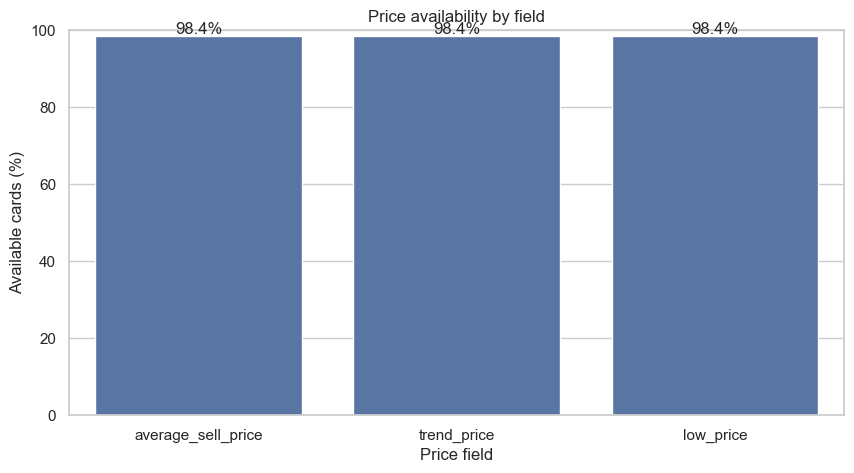

In [13]:
ax = sns.barplot(
    data=price_availability,
    x="price_field",
    y="available_percent"
)

plt.title("Price availability by field")
plt.xlabel("Price field")
plt.ylabel("Available cards (%)")
plt.ylim(0, 100)

# Mostramos el porcentaje exacto encima de cada barra.
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

## Distribucion de rarezas

La rareza es una variable importante en el mercado de cartas. Vamos a revisar que rarezas aparecen con mas frecuencia en la muestra.

In [15]:
rarity_counts = (
    df_cards["rarity"]
    .fillna("Unknown")
    .value_counts()
    .reset_index()
)

rarity_counts.columns = ["rarity", "count"]

rarity_counts.head(10)

,rarity,count
0,Rare Holo,119
1,Common,43
2,Rare,37
3,Uncommon,25
4,Unknown,13
5,Promo,6
6,Rare Holo GX,2
7,Rare Holo V,2
8,Rare Holo EX,2
9,Rare Ultra,1


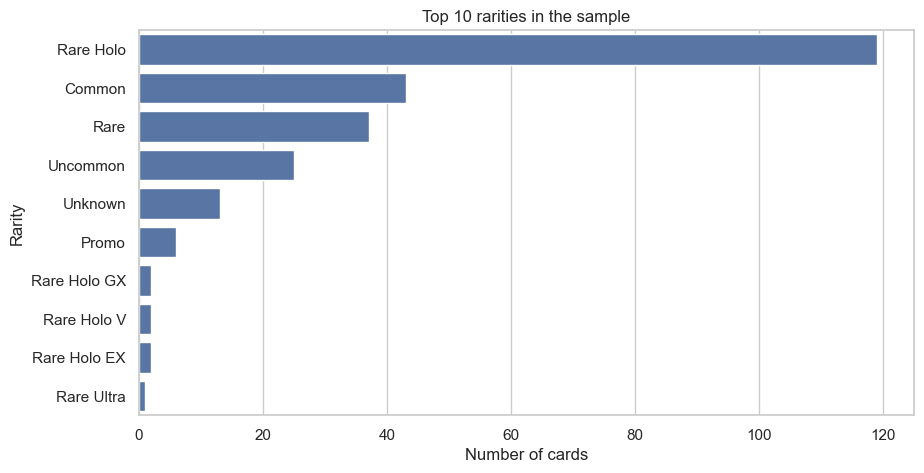

In [16]:
top_rarities = rarity_counts.head(10)

sns.barplot(
    data=top_rarities,
    y="rarity",
    x="count"
)

plt.title("Top 10 rarities in the sample")
plt.xlabel("Number of cards")
plt.ylabel("Rarity")
plt.show()

## Distribucion de precios

Los precios de cartas coleccionables suelen estar sesgados: muchas cartas tienen precios bajos y unas pocas cartas alcanzan valores altos. Analizamos la distribucion del precio seleccionado para entender este comportamiento.

In [17]:
def select_price(row):
    # Priorizamos average_sell_price. Si falta, usamos trend_price.
    if pd.notna(row["average_sell_price"]):
        return row["average_sell_price"]

    if pd.notna(row["trend_price"]):
        return row["trend_price"]

    return None


df_cards["selected_price"] = df_cards.apply(select_price, axis=1)

df_cards[["name", "rarity", "average_sell_price", "trend_price", "selected_price"]].head()

,name,rarity,average_sell_price,trend_price,selected_price
0,Aggron,Rare Holo,3.04,3.20,3.04
1,Weedle,Common,0.12,0.11,0.12
2,Ampharos,Rare Holo,4.85,4.57,4.85
3,Ampharos,Rare Holo,3.18,1.86,3.18
4,Bulbasaur,Common,0.74,0.77,0.74


In [18]:
df_cards["selected_price"].describe()

count    246.000000
mean      23.170407
std       55.248252
min        0.000000
25%        0.302500
50%        4.825000
75%       17.652500
max      484.100000
Name: selected_price, dtype: float64

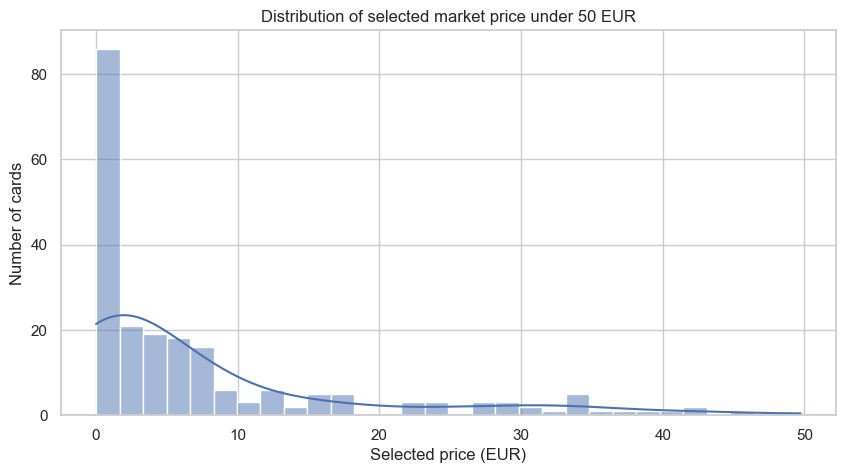

In [20]:
sns.histplot(
    data=df_cards[df_cards["selected_price"] <= 50],
    x="selected_price",
    bins=30,
    kde=True
)

plt.title("Distribution of selected market price under 50 EUR")
plt.xlabel("Selected price (EUR)")
plt.ylabel("Number of cards")
plt.show()

## Precio por rareza

Ahora analizamos si existen diferencias de precio entre rarezas. Esto nos ayuda a entender si la rareza puede explicar parte del valor de mercado.

In [21]:
price_by_rarity = (
    df_cards
    .dropna(subset=["selected_price"])
    .groupby("rarity")
    .agg(
        card_count=("id", "count"),
        mean_price=("selected_price", "mean"),
        median_price=("selected_price", "median"),
        max_price=("selected_price", "max"),
    )
    .reset_index()
    .sort_values("median_price", ascending=False)
)

price_by_rarity.head(10)

,rarity,card_count,mean_price,median_price,max_price
5,Rare Holo GX,2,24.555000,24.555,33.54
1,Promo,2,14.795000,14.795,24.79
7,Rare Ultra,1,11.620000,11.620,11.62
3,Rare Holo,119,36.349748,9.090,484.10
4,Rare Holo EX,2,8.880000,8.880,10.34
6,Rare Holo V,2,2.585000,2.585,2.79
2,Rare,37,13.794324,1.930,112.48
8,Uncommon,25,0.474400,0.150,4.06
0,Common,43,0.300698,0.120,3.13


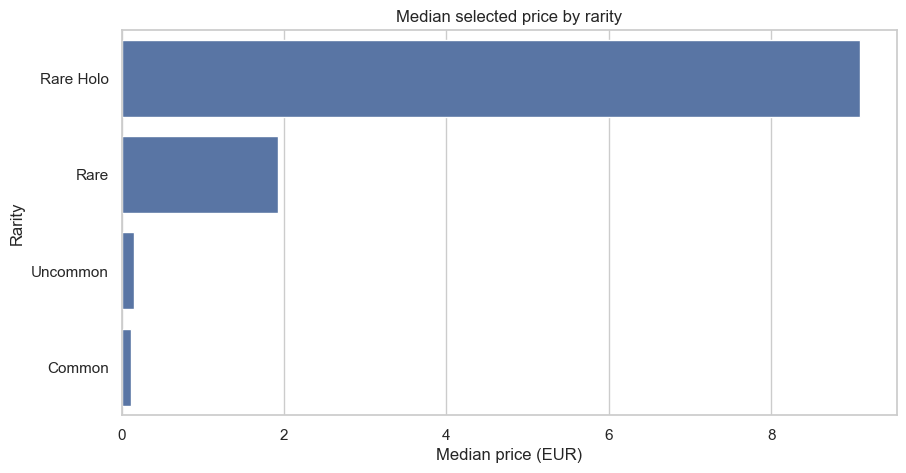

In [22]:
top_rarity_prices = price_by_rarity[price_by_rarity["card_count"] >= 3].head(10)

sns.barplot(
    data=top_rarity_prices,
    y="rarity",
    x="median_price"
)

plt.title("Median selected price by rarity")
plt.xlabel("Median price (EUR)")
plt.ylabel("Rarity")
plt.show()

## Cartas con mayor precio

Identificamos las cartas mas caras de la muestra para entender que casos extremos elevan la media de precios.

In [23]:
top_expensive_cards = (
    df_cards
    .dropna(subset=["selected_price"])
    .sort_values("selected_price", ascending=False)
    .loc[:, ["id", "name", "set_name", "rarity", "selected_price", "image_large"]]
    .head(10)
)

top_expensive_cards

,id,name,set_name,rarity,selected_price,image_large
79,gym2-2,Blaine's Charizard,Gym Challenge,Rare Holo,484.10,https://images.pokemontcg.io/gym2/2_hires.png
101,base1-1,Alakazam,Base,Rare Holo,385.00,https://images.pokemontcg.io/base1/1_hires.png
46,si1-1,Mew,Southern Islands,None,284.79,https://images.pokemontcg.io/si1/1_hires.png
216,base6-3,Charizard,Legendary Collection,Rare Holo,259.80,https://images.pokemontcg.io/base6/3_hires.png
162,base4-4,Charizard,Base Set 2,Rare Holo,228.83,https://images.pokemontcg.io/base4/4_hires.png
208,gym2-4,Erika's Venusaur,Gym Challenge,Rare Holo,193.63,https://images.pokemontcg.io/gym2/4_hires.png
21,ecard2-H2,Arcanine,Aquapolis,Rare Holo,168.81,https://images.pokemontcg.io/ecard2/H2_hires.png
201,base3-5,Gengar,Fossil,Rare Holo,153.32,https://images.pokemontcg.io/base3/5_hires.png
10,ru1-1,Venusaur,Pokémon Rumble,None,131.55,https://images.pokemontcg.io/ru1/1_hires.png
127,base3-4,Dragonite,Fossil,Rare Holo,122.31,https://images.pokemontcg.io/base3/4_hires.png


In [24]:
top_expensive_cards[["name", "set_name", "rarity", "selected_price"]]

,name,set_name,rarity,selected_price
79,Blaine's Charizard,Gym Challenge,Rare Holo,484.10
101,Alakazam,Base,Rare Holo,385.00
46,Mew,Southern Islands,None,284.79
216,Charizard,Legendary Collection,Rare Holo,259.80
162,Charizard,Base Set 2,Rare Holo,228.83
208,Erika's Venusaur,Gym Challenge,Rare Holo,193.63
21,Arcanine,Aquapolis,Rare Holo,168.81
201,Gengar,Fossil,Rare Holo,153.32
10,Venusaur,Pokémon Rumble,None,131.55
127,Dragonite,Fossil,Rare Holo,122.31


## Imagenes oficiales disponibles

Para crear el dataset sintetico necesitamos imagenes limpias de cartas. Revisamos cuantas cartas tienen URL de imagen oficial.

In [25]:
image_availability = pd.DataFrame({
    "image_field": ["image_small", "image_large"],
    "available_count": [
        df_cards["image_small"].notna().sum(),
        df_cards["image_large"].notna().sum(),
    ],
})

image_availability["available_percent"] = (
    image_availability["available_count"] / len(df_cards) * 100
).round(2)

image_availability

,image_field,available_count,available_percent
0,image_small,250,100.0
1,image_large,250,100.0


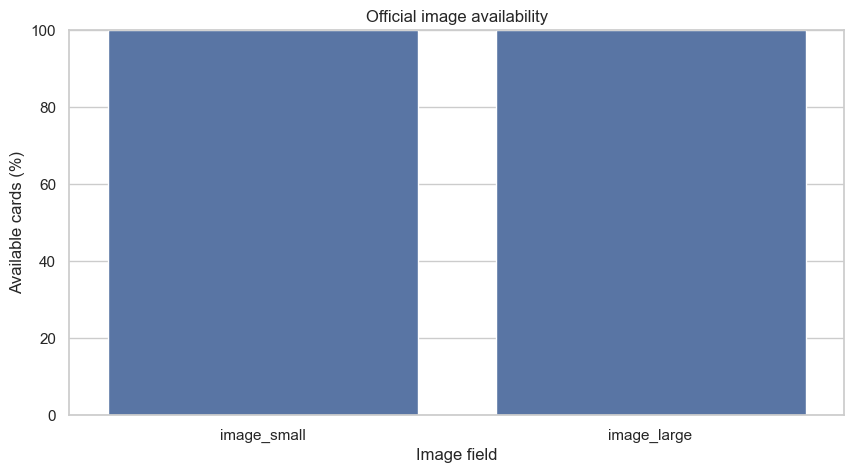

In [26]:
sns.barplot(
    data=image_availability,
    x="image_field",
    y="available_percent"
)

plt.title("Official image availability")
plt.xlabel("Image field")
plt.ylabel("Available cards (%)")
plt.ylim(0, 100)
plt.show()

In [27]:
df_cards[["id", "name", "image_large"]].head()

,id,name,image_large
0,hgss4-1,Aggron,https://images.pokemontcg.io/hgss4/1_hires.png
1,xy5-1,Weedle,https://images.pokemontcg.io/xy5/1_hires.png
2,pl1-1,Ampharos,https://images.pokemontcg.io/pl1/1_hires.png
3,dp3-1,Ampharos,https://images.pokemontcg.io/dp3/1_hires.png
4,det1-1,Bulbasaur,https://images.pokemontcg.io/det1/1_hires.png


## Conclusiones iniciales del EDA

A partir de la muestra analizada, observamos:

- La Pokemon TCG API devuelve campos utiles para el proyecto: ID, nombre, set, rareza, imagenes oficiales y precios de Cardmarket.
- La mayoria de cartas de la muestra tienen precios disponibles en `averageSellPrice` o `trendPrice`.
- Los precios estan muy sesgados: hay muchas cartas baratas y pocas cartas con precios muy altos.
- La media de precios puede verse afectada por outliers, como cartas tipo Charizard.
- La rareza influye en el precio, aunque no lo explica todo por si sola.
- Practicamente todas las cartas tienen imagen oficial disponible.
- Las imagenes oficiales son utiles como base para crear un dataset sintetico, pero no representan cartas dañadas reales.

Por tanto, la API es adecuada para:
1. Busqueda y seleccion de cartas.
2. Obtencion de precio base.
3. Obtencion de imagenes limpias para generar datos sinteticos.

No es adecuada por si sola para:
1. Entrenar un modelo real de condicion fisica.
2. Aprender desgaste real sin aplicar transformaciones o usar imagenes reales etiquetadas.

## Guardado de muestra procesada

Guardamos la muestra normalizada en `data/processed`. Este archivo puede servir para futuras pruebas de EDA, prototipos o descarga de imagenes.

In [28]:
output_path = "../data/processed/pokemon_tcg_sample.csv"

df_cards.to_csv(output_path, index=False)

output_path

'../data/processed/pokemon_tcg_sample.csv'